In [1]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

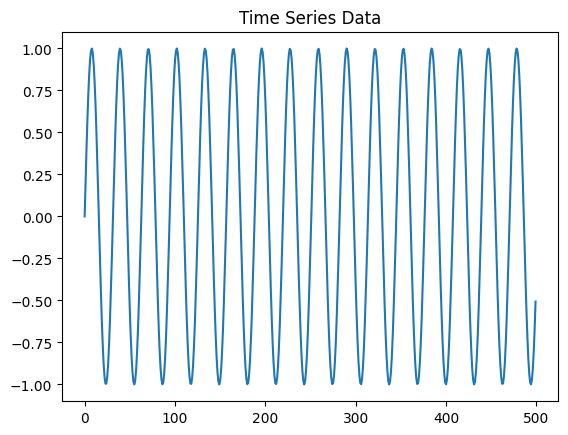

In [2]:
# Generate simple time-series data (sine wave)

x = np.linspace(0, 100, 500)       # 500 points
data = np.sin(x)                   # sine wave

# Plot data
plt.plot(data)
plt.title("Time Series Data")
plt.show()

In [3]:
# Function to create sequences

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

# Sequence length
seq_length = 20

# Create dataset
X, y = create_sequences(data, seq_length)

# Convert to tensors
X = torch.FloatTensor(X).unsqueeze(-1)
y = torch.FloatTensor(y)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([480, 20, 1])
Output shape: torch.Size([480])


In [4]:
# Define RNN model
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()

        # RNN layer
        self.rnn = nn.RNN(
            input_size=1,      # 1 feature
            hidden_size=32,    # number of hidden units
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Pass through RNN
        out, _ = self.rnn(x)

        # Take last time step output
        out = out[:, -1, :]

        # Pass through FC layer
        out = self.fc(out)

        return out

In [5]:
# Create model
rnn_model = RNNModel()

# Loss function (MSE for regression)
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

In [6]:
# Training RNN

epochs = 20
rnn_losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    # Forward pass
    output = rnn_model(X)

    # Compute loss
    loss = criterion(output.squeeze(), y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    rnn_losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7194
Epoch 2, Loss: 0.5748
Epoch 3, Loss: 0.4754
Epoch 4, Loss: 0.3849
Epoch 5, Loss: 0.2963
Epoch 6, Loss: 0.2091
Epoch 7, Loss: 0.1651
Epoch 8, Loss: 0.1249
Epoch 9, Loss: 0.0736
Epoch 10, Loss: 0.0461
Epoch 11, Loss: 0.0356
Epoch 12, Loss: 0.0212
Epoch 13, Loss: 0.0045
Epoch 14, Loss: 0.0121
Epoch 15, Loss: 0.0098
Epoch 16, Loss: 0.0163
Epoch 17, Loss: 0.0129
Epoch 18, Loss: 0.0058
Epoch 19, Loss: 0.0065
Epoch 20, Loss: 0.0019


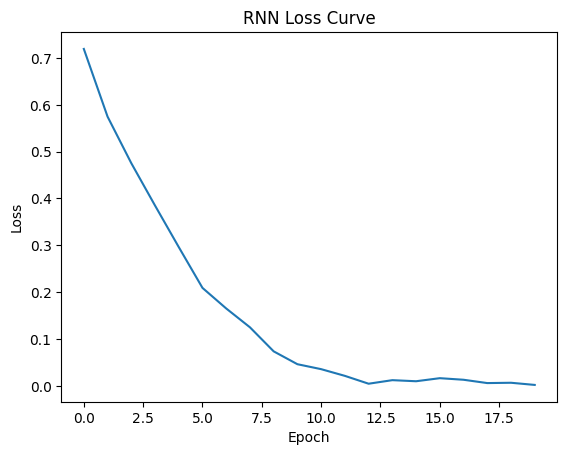

In [7]:
# Plot RNN loss
plt.plot(rnn_losses)
plt.title("RNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [8]:
# Calculate RMSE
rmse = torch.sqrt(loss)
print(f"RNN RMSE: {rmse.item():.4f}")

RNN RMSE: 0.0437


In [9]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Pass through LSTM
        out, _ = self.lstm(x)

        # Take last time step
        out = out[:, -1, :]

        # Fully connected
        out = self.fc(out)

        return out

In [10]:
# Create model
lstm_model = LSTMModel()

# Loss and optimizer
criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

In [11]:
# Train LSTM

epochs = 20
lstm_losses = []

for epoch in range(epochs):

    optimizer_lstm.zero_grad()

    output = lstm_model(X)

    loss = criterion_lstm(output.squeeze(), y)

    loss.backward()
    optimizer_lstm.step()

    lstm_losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.4903
Epoch 2, Loss: 0.4418
Epoch 3, Loss: 0.3957
Epoch 4, Loss: 0.3509
Epoch 5, Loss: 0.3097
Epoch 6, Loss: 0.2707
Epoch 7, Loss: 0.2255
Epoch 8, Loss: 0.1729
Epoch 9, Loss: 0.1186
Epoch 10, Loss: 0.0678
Epoch 11, Loss: 0.0272
Epoch 12, Loss: 0.0122
Epoch 13, Loss: 0.0374
Epoch 14, Loss: 0.0272
Epoch 15, Loss: 0.0048
Epoch 16, Loss: 0.0080
Epoch 17, Loss: 0.0115
Epoch 18, Loss: 0.0110
Epoch 19, Loss: 0.0082
Epoch 20, Loss: 0.0063


In [12]:
rmse_lstm = torch.sqrt(loss)
print(f"LSTM RMSE: {rmse_lstm.item():.4f}")

LSTM RMSE: 0.0792


In [13]:
# Define GRU model
class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()

        # GRU layer
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Pass through GRU
        out, _ = self.gru(x)

        # Take last time step
        out = out[:, -1, :]

        # Fully connected
        out = self.fc(out)

        return out

In [14]:
# Initialize GRU
gru_model = GRUModel()

criterion_gru = nn.MSELoss()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.01)

In [15]:
# Train GRU
epochs = 20
gru_losses = []

for epoch in range(epochs):

    optimizer_gru.zero_grad()

    output = gru_model(X)

    loss = criterion_gru(output.squeeze(), y)

    loss.backward()
    optimizer_gru.step()

    gru_losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6320
Epoch 2, Loss: 0.5536
Epoch 3, Loss: 0.4918
Epoch 4, Loss: 0.4389
Epoch 5, Loss: 0.3906
Epoch 6, Loss: 0.3429
Epoch 7, Loss: 0.2932
Epoch 8, Loss: 0.2423
Epoch 9, Loss: 0.1934
Epoch 10, Loss: 0.1483
Epoch 11, Loss: 0.1082
Epoch 12, Loss: 0.0717
Epoch 13, Loss: 0.0334
Epoch 14, Loss: 0.0071
Epoch 15, Loss: 0.0099
Epoch 16, Loss: 0.0211
Epoch 17, Loss: 0.0166
Epoch 18, Loss: 0.0083
Epoch 19, Loss: 0.0064
Epoch 20, Loss: 0.0081


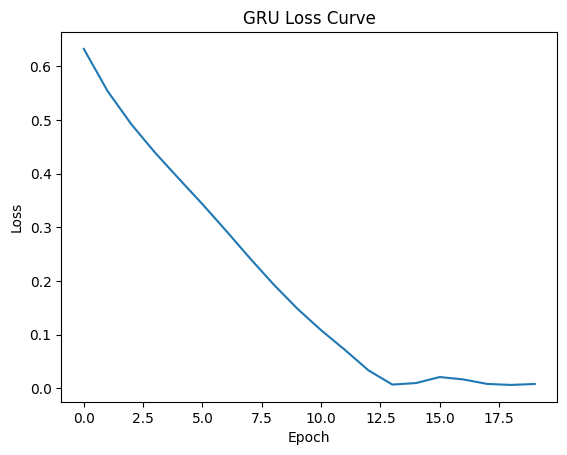

In [16]:
# Plot GRU Loss
plt.plot(gru_losses)
plt.title("GRU Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [17]:
# Compute GRU MSE
rmse_gru = torch.sqrt(loss)
print(f"GRU RMSE: {rmse_gru.item():.4f}")

GRU RMSE: 0.0902


In [18]:
import matplotlib.pyplot as plt

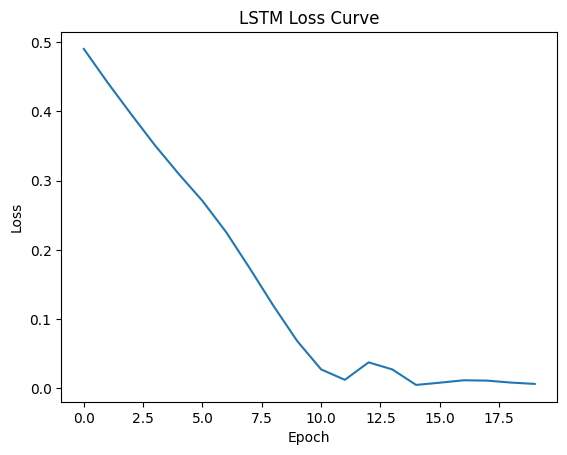

In [19]:
plt.plot(lstm_losses)
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()